In [2]:
# DECONVOLUTION
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.interpolate import interp1d

Text(0.5, 1.0, 'Histogram of PSF Beads noise')

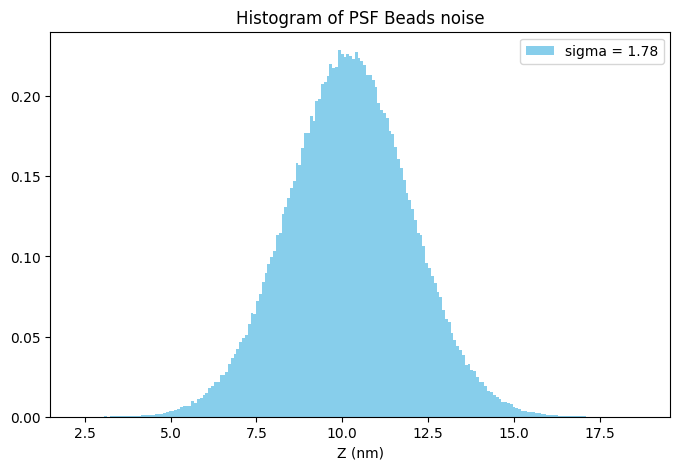

In [3]:
data = np.loadtxt('beads_noise.txt', skiprows=1)  # Cambia con il tuo nome file
z_data = data[:, 0]  # Colonna Z (nm)
t_data = data[:, 1]  # Colonna Tempo (sec)
sigma = np.std(z_data)

plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(z_data, bins=200, density=True, color='skyblue', label="sigma = {:.2f}".format(sigma))
plt.xlabel('Z (nm)')
plt.legend()
plt.title('Histogram of PSF Beads noise')

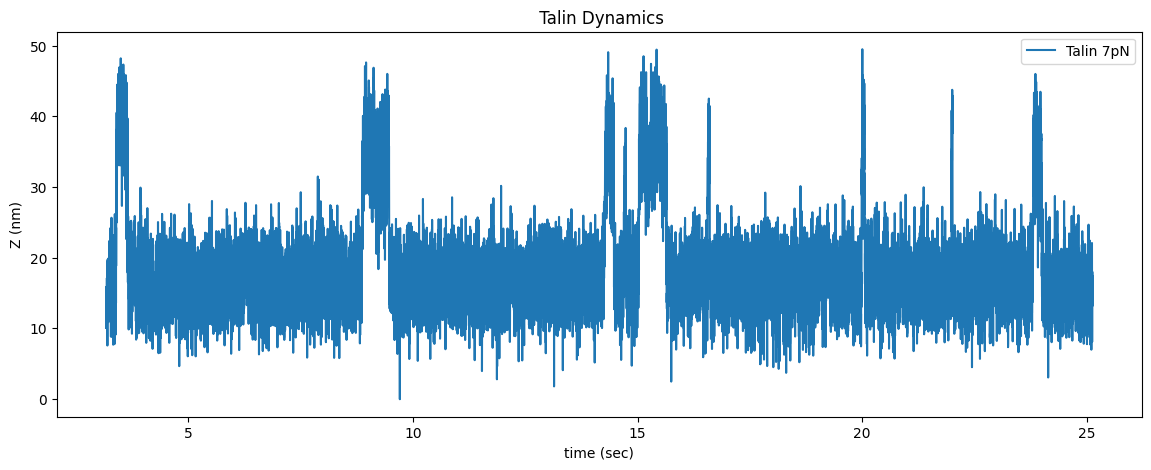

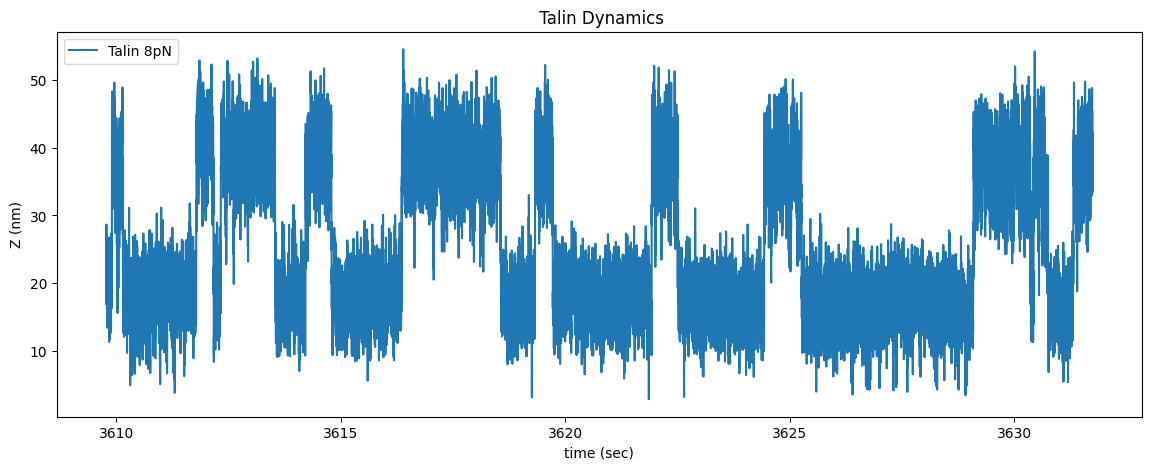

In [4]:
# Upload protein transition data 

talin_7 = np.loadtxt("Talin_7p7_pN.txt", skiprows=1) 
talin_8 = np.loadtxt("Talin_8pN_1.txt", skiprows=1)

x1 = talin_7[:, 1] 
t1 = talin_7[:, 0]
x2 = talin_8[:, 1]
t2= talin_8[:, 0]

for i, q, label in zip([x1,x2], [t1,t2], ["Talin 7pN", "Talin 8pN"]):
    
    plt.figure(figsize=(14, 5))
    plt.plot(q[:30000], i[:30000],label=label)
    plt.legend()
    plt.xlabel('time (sec)')
    plt.ylabel('Z (nm)')
    plt.title(" Talin Dynamics")

# def langevin(x, F, x_dag = ):
#     return 4 * dG * (1/4 * ((x- xdag)/ xdag)**4 - 0.5 *((x - xdag)/ xdag)**2 ) - F *x 
# U1 = 

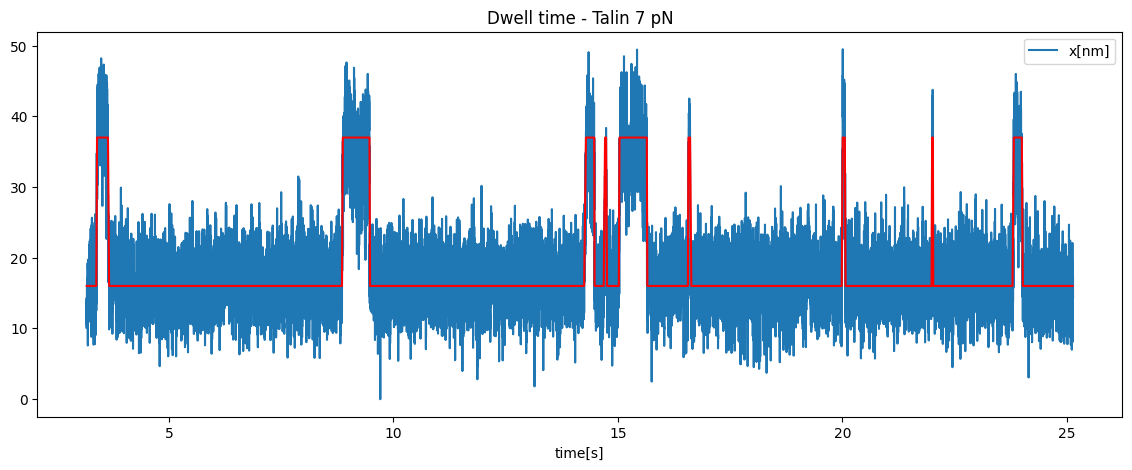

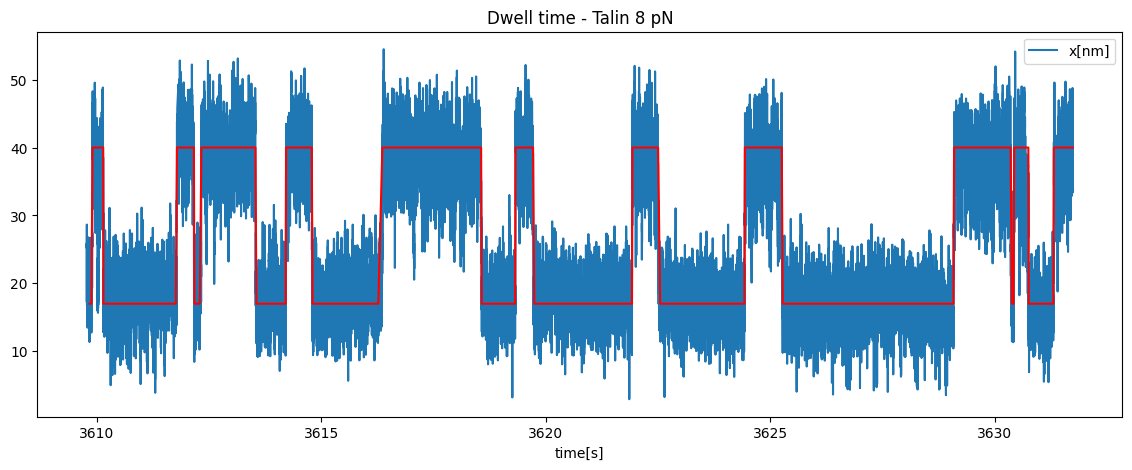

In [5]:
# RATE FROM DWELL TIME

df7 = pd.DataFrame({"time[s]": t1, "x[nm]":x1})
df8 = pd.DataFrame({"time[s]": t2, "x[nm]":x2})

x1 = df7["x[nm]"].values
t1 = df7["time[s]"].values
x2 = df8["x[nm]"].values
t2 = df8["time[s]"].values

mask = np.full_like(x1, np.nan)
mask[x1 < 13] = 16  # folded
mask[x1 > 35] = 37

valid = ~np.isnan(mask[:30000])
plt.figure(figsize=(14, 5))
ax = plt.gca() 
df7.iloc[:30000, :30000].plot(x=df7.columns[0], y=df7.columns[1], ax=ax)
plt.plot(t1[:30000][valid], mask[:30000][valid], color='red', linewidth=1.5)   
plt.title("Dwell time - Talin 7 pN")
plt.show()
#-----------------------------------
mask = np.full_like(x2, np.nan)
mask[x2 < 13] = 17 # folded
mask[x2 > 34] = 40

valid = ~np.isnan(mask[:30000])
plt.figure(figsize=(14, 5))
ax = plt.gca() 
df8.iloc[:30000, :30000].plot(x=df8.columns[0], y=df8.columns[1], ax=ax)
plt.plot(t2[:30000][valid], mask[:30000][valid], color='red', linewidth=1.5)   
plt.title("Dwell time - Talin 8 pN")
plt.show()

In [6]:

result_style = []

def process_file(filename, fold_state, unfold_state):
## fortran file 
    data = np.loadtxt(filename, skiprows=1)
    t = data[:, 0]
    x = data[:, 1]

    state = np.full_like(x, np.nan)
    state[x < low_threshold] = fold_state   # folded
    state[x > up_threshold] = unfold_state       # unfolded

    valid_indices = ~np.isnan(state)
    state = state[valid_indices]
    t = t[valid_indices]

    t_fold, t_unfold = [], [] 

    last_state = state[0]
    last_time = t[0]

    for i in range(1, len(state)):
        if state[i] != last_state:
            dt = t[i] - last_time

            if last_state == unfold_state and state[i] == fold_state:
                t_unfold.append(dt)
            elif last_state == fold_state  and state[i] == unfold_state:
                t_fold.append(dt)

            last_state = state[i]
            last_time = t[i]

    # Ultimo segmento (facoltativo)
    dt = t[-1] - last_time
    if last_state == unfold_state:
        t_unfold.append(dt)
    elif last_state == fold_state:
        t_fold.append(dt)

    min_dwell = 0.0 
    t_fold = [dt for dt in t_fold if dt >= min_dwell]
    t_unfold = [dt for dt in t_unfold if dt >= min_dwell]

    folding_rate = 1 / np.mean(t_unfold) if t_fold else 0
    unfolding_rate = 1 / np.mean(t_fold) if t_unfold else 0


    return  folding_rate, unfolding_rate, t_unfold, t_fold 

results = []
up_threshold = 35
low_threshold = 21
folding_rate, unfolding_rate, t_up_list, t_down_list = process_file("Talin_7p7_pN.txt", 16, 37)

results.append({
    "folding_rate": folding_rate,
    "unfolding_rate": unfolding_rate,
    "t_up_list": t_up_list,
    "t_down_list": t_down_list
})

df_7 = pd.DataFrame(results)
df_7


,folding_rate,unfolding_rate,t_up_list,t_down_list
0,3.414032,0.82433,"[0.24609369999999986, 0.3144530999999997, 0.01...","[0.23144529999999985, 5.226562500000001, 0.003..."


In [7]:

#-----------------------
results_8 = []
up_threshold = 35
low_threshold = 21
folding_rate, unfolding_rate, t_up_list, t_down_list = process_file("Talin_8pN_1.txt", 21, 40)

results_8.append({
    "folding_rate": folding_rate,
    "unfolding_rate": unfolding_rate,
    "t_up_list": t_up_list,
    "t_down_list": t_down_list
})

df_8 = pd.DataFrame(results_8)
df_8

,folding_rate,unfolding_rate,t_up_list,t_down_list
0,4.009861,2.377891,"[0.11130000000002838, 0.0079000000000633, 0.09...","[0.12789999999995416, 0.024400000000241562, 0...."


C:\Users\bulga\AppData\Local\Temp\ipykernel_17984\1949638530.py:11: RuntimeWarning: divide by zero encountered in log
  U_x = -np.log(p_x)


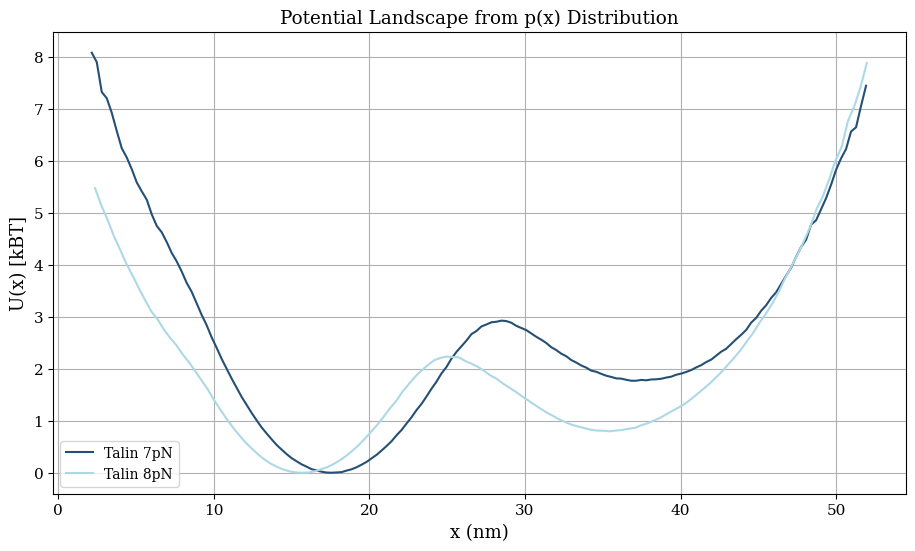

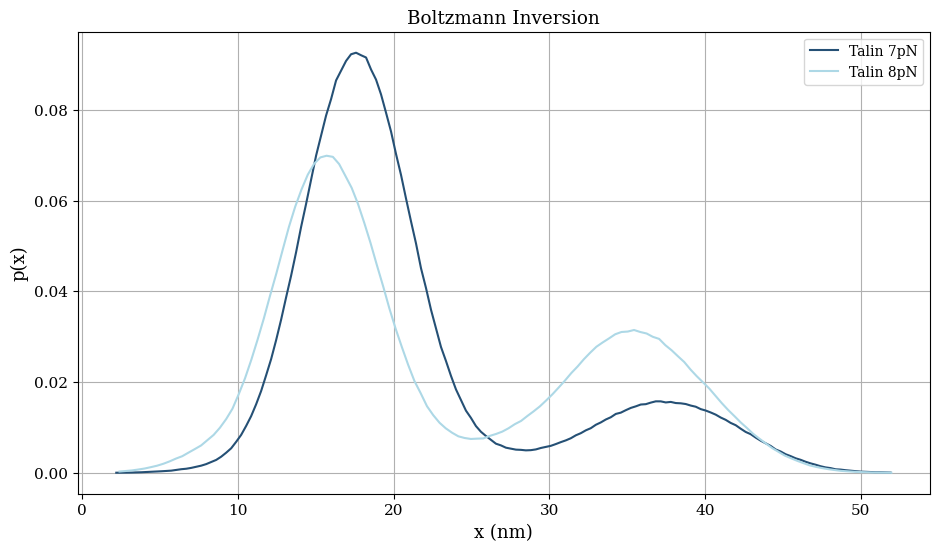

In [26]:
# plot Potential landscape - Boltzmann distribution

plt.figure(figsize=(11, 6))
P, bin_c, U = [], [], []

for i, label, c in zip([x1, x2], ['Talin 7pN', 'Talin 8pN'], ["#255075", "lightblue"]):
    hist, bin_edges = np.histogram(i, bins=200, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    p_x = hist 
    U_x = -np.log(p_x)  

    # Normalizza il minimo del potenziale a 0
    U_x -= np.min(U_x)

    mask = (bin_centers > 2) & (bin_centers < 52)
    bin_centers_cut = bin_centers[mask]
    U_x_cut = U_x[mask]
    p_x_cut = p_x[mask]

    bin_c.append(bin_centers_cut)
    P.append(p_x_cut)
    U.append(U_x_cut)

    plt.plot(bin_centers_cut, U_x_cut, label= f"{label}", c=c)
    plt.xlabel("x (nm)")
    plt.ylabel("U(x) [kBT]")
    plt.title("Potential Landscape from p(x) Distribution")
    plt.grid(True)
   # plt.ylim(-0.5, 6)
    plt.legend()
   
plt.show()

plt.figure(figsize=(11, 6))
plt.plot(bin_c[0], P[0], label="Talin 7pN", c="#255075")
plt.plot(bin_c[1], P[1], label="Talin 8pN", c="lightblue")
plt.xlabel("x (nm)")
plt.ylabel("p(x)")
plt.grid(True)
plt.title("Boltzmann Inversion")
plt.legend()

plt.show()

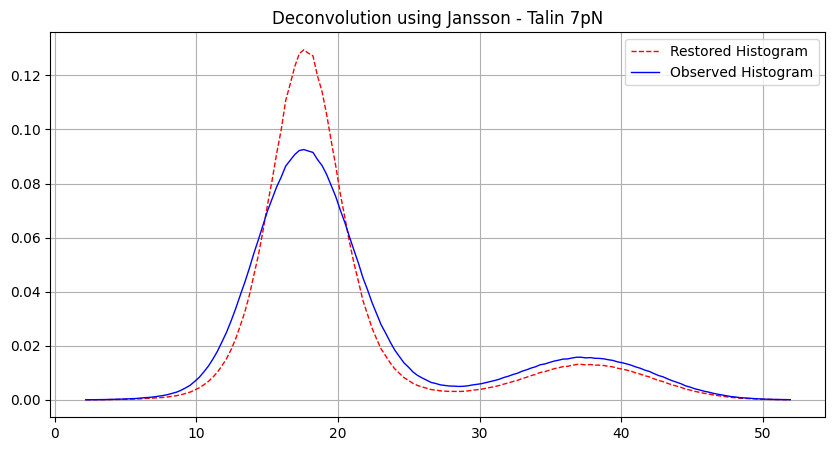

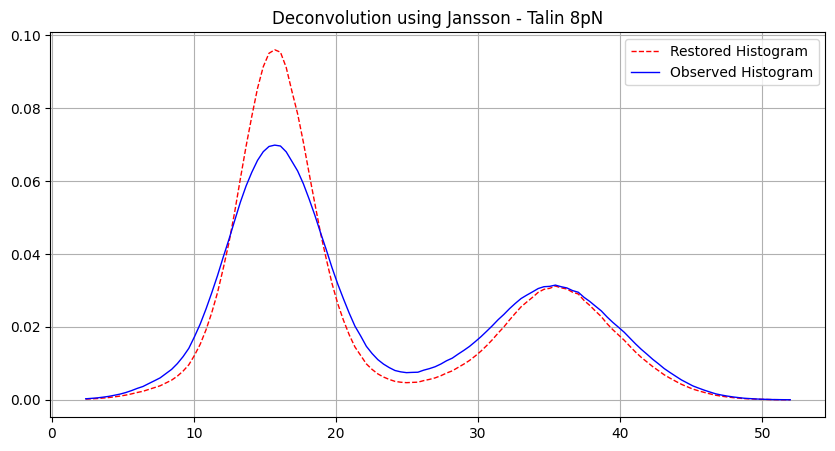

In [9]:
#  DECONVOLUTION JOHNSON 

def jansson_deconvolution(observed, kernel, iterations=1000, alpha=0.05):
    from scipy.signal import fftconvolve

    kernel = kernel / np.sum(kernel)
    estimate = np.copy(observed)
    
    for _ in range(iterations):
        reconvolved = fftconvolve(estimate, kernel, mode='same')
        # usa una regolarizzazione minima per evitare annullamenti
        correction = observed - reconvolved
        update = alpha * correction * estimate
        estimate += update
        estimate[estimate < 0] = 0  # forza positività

    return estimate

restored = jansson_deconvolution(P[0], counts, iterations=700, alpha=0.02)
restored /= np.sum(restored) * (bin_c[0][1] - bin_c[0][0]) #!!!!!!!!!!!!!!!! RI NORMALIZZA 

restored2 = jansson_deconvolution(P[1], counts, iterations=700, alpha=0.02)
restored2/= np.sum(restored2) * (bin_c[1][1] - bin_c[1][0]) #!!!!!!!!!!!!!!!! RI NORMALIZZA 

plt.figure(figsize=(10, 5))
plt.plot(bin_c[0], restored, label="Restored Histogram", lw=1, linestyle='--', c="r")
plt.plot(bin_c[0], P[0], label="Observed Histogram", lw=1, c="b")
plt.legend()
plt.title("Deconvolution using Jansson - Talin 7pN")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(bin_c[1], restored2, label="Restored Histogram", lw=1, linestyle='--', c="r")
plt.plot(bin_c[1], P[1], label="Observed Histogram", lw=1, c="b")
plt.legend()
plt.title("Deconvolution using Jansson - Talin 8pN")
plt.grid(True)
plt.show()


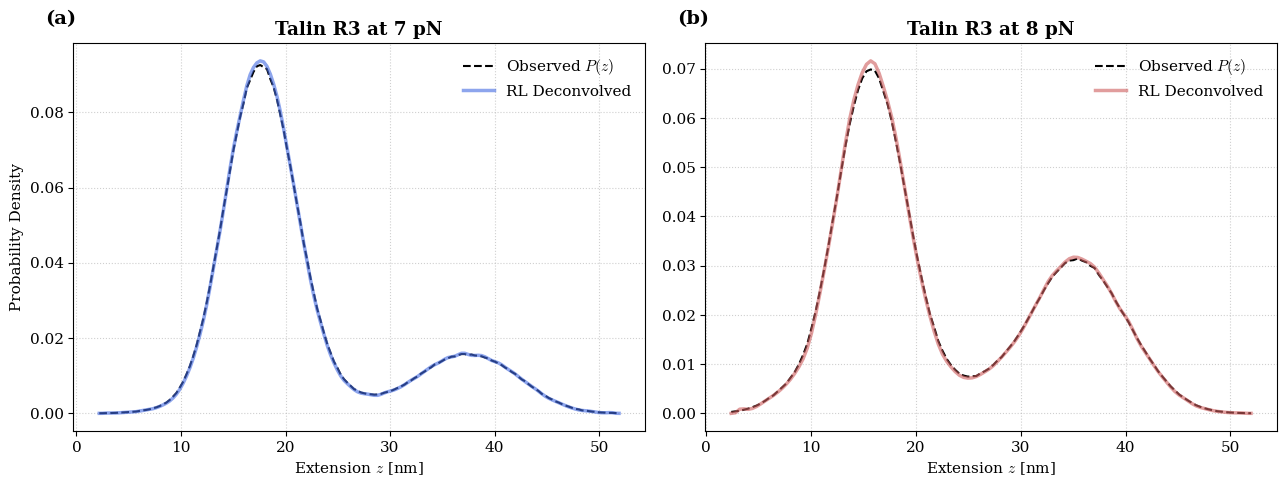

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftshift
from skimage.restoration import richardson_lucy

def deconvolvi_Ux(counts, bin_centers, sigma=3, n_iter=140, kT=4.11):
    # Definizione del kernel Gaussiano per la Point Spread Function (PSF)
    L = int(6 * sigma + 1)
    if L % 2 == 0: L += 1
    x = np.linspace(-3*sigma, 3*sigma, L)
    kernel = np.exp(-x**2 / (2*sigma**2))
    kernel /= kernel.sum()
    
    # Richardson-Lucy Deconvolution
    restored = richardson_lucy(counts, kernel, num_iter=n_iter, clip=False)
    
    # Normalizzazione della densità di probabilità
    dx = bin_centers[1] - bin_centers[0]
    restored = np.maximum(restored, 1e-10) # evita log(0)
    restored /= (restored.sum() * dx)

    # Calcolo dell'energia libera U(x) in unità kT
    U_dec = -np.log(restored)
    U_dec -= np.min(U_dec) # Offset al minimo

    # Allineamento (shift) basato sul minimo della distribuzione osservata
    i0 = np.nanargmin(-np.log(counts + 1e-7))
    i1 = np.nanargmin(U_dec)
    shift = bin_centers[i0] - bin_centers[i1]
    bin_centers_shifted = bin_centers + shift 

    return bin_centers_shifted, U_dec, restored

# --- ELABORAZIONE E PLOT ---

plt.rcParams.update({'font.family': 'serif', 'font.size': 11, 'mathtext.fontset': 'cm'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Risoluzione per i due dataset (es. 7pN e 8pN)
# Dataset 1
bc1_s, U1, res1 = deconvolvi_Ux(P[0], bin_c[0], sigma=1.5, n_iter=30)
ax1.plot(bin_c[0], P[0], '--', color="black", alpha=1, label="Observed $P(z)$")
ax1.plot(bc1_s, res1, color='royalblue', lw=2.5, alpha=0.6, label="RL Deconvolved")
ax1.set_title("Talin R3 at 7 pN", fontweight='bold')
ax1.set_xlabel("Extension $z$ [nm]")
ax1.set_ylabel("Probability Density")
ax1.legend(frameon=False)
ax1.text(-0.05, 1.05, "(a)", transform=ax1.transAxes, fontsize=14, fontweight='bold')

# Dataset 2
bc2_s, U2, res2 = deconvolvi_Ux(P[1], bin_c[1], sigma=1.5, n_iter=30)
ax2.plot(bin_c[1], P[1], '--', alpha=1, color='black', label="Observed $P(z)$")
ax2.plot(bc2_s, res2, color='indianred', lw=2.5,  alpha=0.6, label="RL Deconvolved")
ax2.set_title("Talin R3 at 8 pN", fontweight='bold')
ax2.set_xlabel("Extension $z$ [nm]")
ax2.legend(frameon=False)
ax2.text(-0.05, 1.05, "(b)", transform=ax2.transAxes, fontsize=14, fontweight='bold')

for ax in [ax1, ax2]: ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

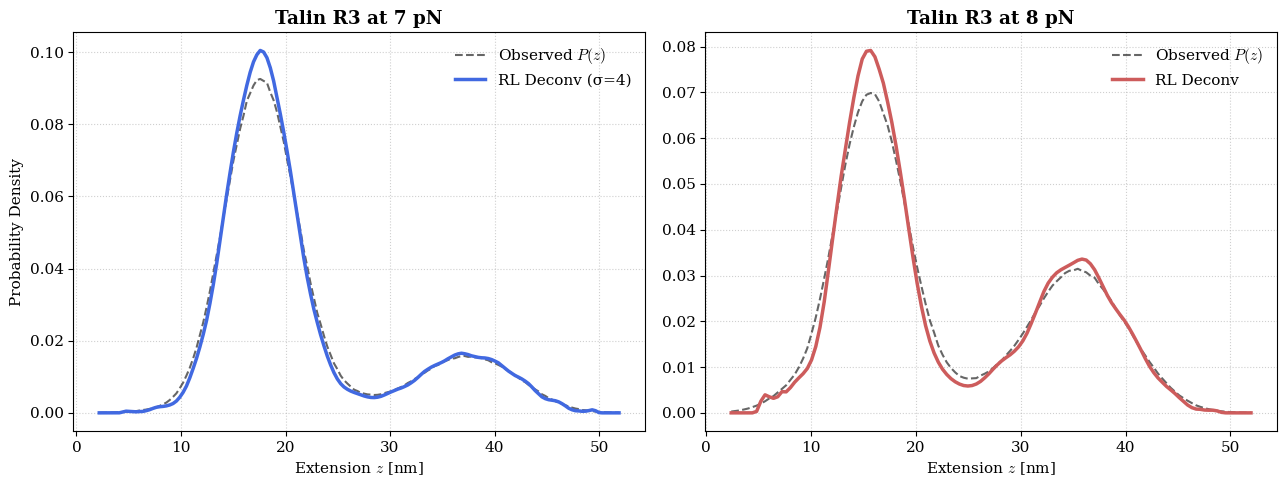

Altezza barriera (max U) Dataset 1: 20.73 kT


In [11]:
# 2nd lucy 


def deconvolvi_Ux(counts, bin_centers, sigma, n_iter, kT=4.11):
    """
    Esegue la deconvolution di Richardson-Lucy e calcola il potenziale U(z).
    """
    # 1. Definizione del kernel Gaussiano (PSF)
    L = int(6 * sigma + 1)
    if L % 2 == 0: L += 1
    x_k = np.linspace(-3*sigma, 3*sigma, L)
    kernel = np.exp(-x_k**2 / (2*sigma**2))
    kernel /= kernel.sum()
    
    # 2. Richardson-Lucy Deconvolution
    # Questo 'stringe' la probabilità e 'alza' le barriere del potenziale
    restored = richardson_lucy(counts, kernel, num_iter=n_iter, clip=False)
    
    # 3. Normalizzazione
    dx = bin_centers[1] - bin_centers[0]
    restored = np.maximum(restored, 1e-10) # evita log(0)
    restored /= (restored.sum() * dx)

    # 4. Calcolo dell'energia libera U(z) in unità kT
    U_dec = -np.log(restored)
    U_dec -= np.min(U_dec) # Offset al minimo

    # 5. Allineamento (shift)
    i0 = np.nanargmin(-np.log(counts + 1e-7))
    i1 = np.nanargmin(U_dec)
    shift = bin_centers[i0] - bin_centers[i1]
    bin_centers_shifted = bin_centers + shift 

    return bin_centers_shifted, U_dec, restored

# =================================================================
# --- PARAMETRI DA MODIFICARE PER INTENSIFICARE L'AZIONE ---
# =================================================================
SIGMA_VAL = 4  # Aumenta (es. 4.0) per stringere di più i picchi
ITER_VAL  = 400  # Aumenta (es. 300) per alzare di più le barriere
# =================================================================

plt.rcParams.update({'font.family': 'serif', 'font.size': 11, 'mathtext.fontset': 'cm'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Dataset 1 (7 pN) ---
# Usiamo i parametri definiti sopra per vedere il cambiamento
bc1_s, U1, res1 = deconvolvi_Ux(P[0], bin_c[0], sigma=SIGMA_VAL, n_iter=ITER_VAL)

ax1.plot(bin_c[0], P[0], '--', color="black", alpha=0.6, label="Observed $P(z)$")
ax1.plot(bc1_s, res1, color='royalblue', lw=2.5, label=f"RL Deconv (σ={SIGMA_VAL})")
ax1.set_title("Talin R3 at 7 pN", fontweight='bold')
ax1.set_xlabel("Extension $z$ [nm]")
ax1.set_ylabel("Probability Density")
ax1.legend(frameon=False)

# --- Dataset 2 (8 pN) ---
bc2_s, U2, res2 = deconvolvi_Ux(P[1], bin_c[1], sigma=SIGMA_VAL, n_iter=ITER_VAL)

ax2.plot(bin_c[1], P[1], '--', color='black', alpha=0.6, label="Observed $P(z)$")
ax2.plot(bc2_s, res2, color='indianred', lw=2.5, label=f"RL Deconv ")
ax2.set_title("Talin R3 at 8 pN", fontweight='bold')
ax2.set_xlabel("Extension $z$ [nm]")
ax2.legend(frameon=False)

for ax in [ax1, ax2]: 
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Stampa di controllo per vedere se l'energia è cambiata
print(f"Altezza barriera (max U) Dataset 1: {np.max(U1):.2f} kT")

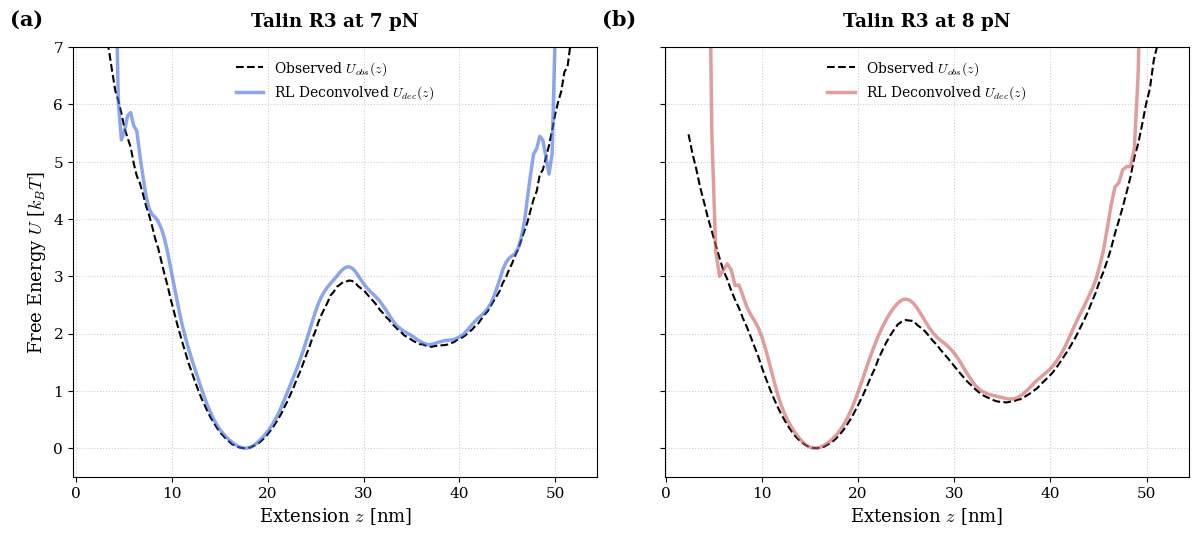

In [12]:
# RESTORING THE POTENTIAL LANDSCAPE

kT = 4.11  # pN * nm
G7 = - np.log(P[0])  
G8 = - np.log(P[1])

# POTENTIAL IN KBT!!
G1 = -np.log(res1)
G2 = - np.log(res2)


# Configurazione stile Tesi
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'mathtext.fontset': 'cm'
})

# Creazione figura unica Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

# Offset per allineare i grafici (il +2.5 che usavi nel codice)
offset = 2.5

# --- Pannello (a): 7 pN ---
# Normalizziamo il minimo del potenziale osservato a zero per confronto
G7_norm = G7 - np.nanmin(G7)
U1_norm = U1 - np.nanmin(U1)

ax1.plot(bin_c[0], G7_norm, color='black', linestyle = "--", alpha=1, lw=1.5, label="Observed $U_{obs}(z)$")
ax1.plot(bc1_s, U1_norm, color='royalblue', lw=2.5, alpha=0.6, label="RL Deconvolved $U_{dec}(z)$")

ax1.set_title("Talin R3 at 7 pN", fontweight='bold', pad=15)
ax1.set_xlabel("Extension $z$ [nm]")
ax1.set_ylabel("Free Energy $U$ [$k_B T$]")
ax1.set_ylim(-0.5, 7)  # Taglio perfetto per evidenziare la barriera
ax1.legend(frameon=False, loc='upper center')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.text(-0.12, 1.05, "(a)", transform=ax1.transAxes, fontsize=15, fontweight='bold')

# --- Pannello (b): 8 pN ---
G8_norm = G8 - np.nanmin(G8)
U2_norm = U2 - np.nanmin(U2)

ax2.plot(bin_c[1], G8_norm, color='black', linestyle = "--", alpha=1, lw=1.5, label="Observed $U_{obs}(z)$")
ax2.plot(bc2_s, U2_norm, color='indianred', lw=2.5, alpha=0.6, label="RL Deconvolved $U_{dec}(z)$")

ax2.set_title("Talin R3 at 8 pN", fontweight='bold', pad=15)
ax2.set_xlabel("Extension $z$ [nm]")
ax2.set_ylim(-0.5, 7) 
ax2.legend(frameon=False, loc='upper center')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.text(-0.12, 1.05, "(b)", transform=ax2.transAxes, fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

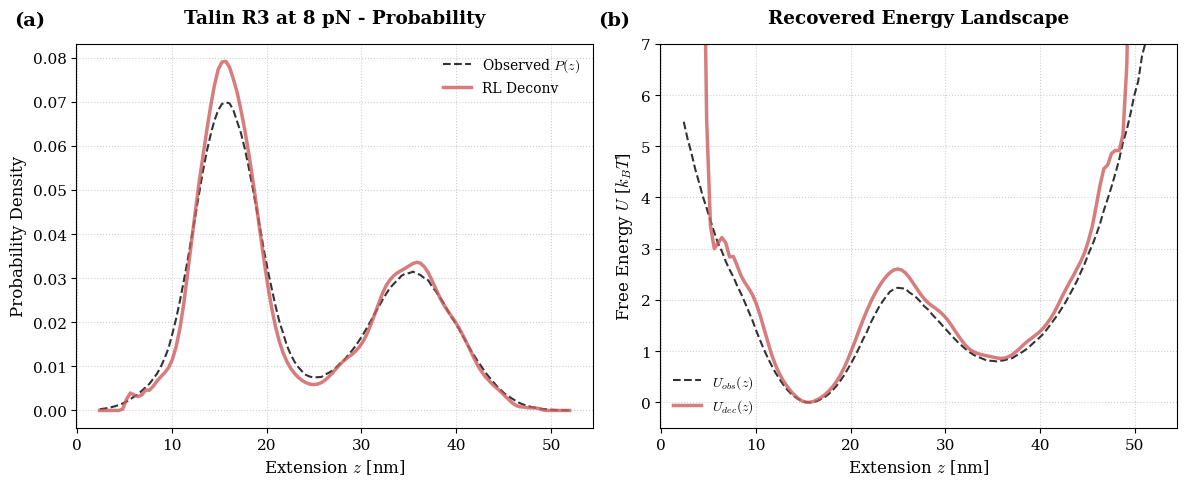

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import richardson_lucy

# --- Definizione parametri e dLc ---
dLc = 19.7  # Esempio di valore per dLc
# Uso dLc^p come richiesto (es. p=1 o p=0.5 a seconda del modello polimerico)
# In questo script lo definiamo come variabile di riferimento
dLcp = dLc**1.0 

def deconvolvi_Ux(counts, bin_centers, sigma, n_iter):
    # 1. Definizione del kernel Gaussiano (PSF)
    L = int(6 * sigma + 1)
    if L % 2 == 0: L += 1
    x_k = np.linspace(-3*sigma, 3*sigma, L)
    kernel = np.exp(-x_k**2 / (2*sigma**2))
    kernel /= kernel.sum()
    
    # 2. Richardson-Lucy Deconvolution
    restored = richardson_lucy(counts, kernel, num_iter=n_iter, clip=False)
    
    # 3. Normalizzazione
    dx = bin_centers[1] - bin_centers[0]
    restored = np.maximum(restored, 1e-10)
    restored /= (restored.sum() * dx)

    # 4. Calcolo dell'energia libera U(z) in unità kT
    U_dec = -np.log(restored)
    U_dec -= np.min(U_dec)

    # 5. Allineamento
    i0 = np.nanargmin(-np.log(counts + 1e-7))
    i1 = np.nanargmin(U_dec)
    shift = bin_centers[i0] - bin_centers[i1]
    bin_centers_shifted = bin_centers + shift 

    return bin_centers_shifted, U_dec, restored

# Parametri ottimizzati
SIGMA_VAL = 4 
ITER_VAL  = 400 

# Esecuzione deconvolution per 8 pN (indice 1 nel tuo dataset P)
bc2_s, U2, res2 = deconvolvi_Ux(P[1], bin_c[1], sigma=SIGMA_VAL, n_iter=ITER_VAL)

# --- Configurazione Stile Tesi ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'mathtext.fontset': 'cm'
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Pannello (a): PSF e Probability Density ---
ax1.plot(bin_c[1], P[1], '--', color='black', alpha=0.8, label="Observed $P(z)$")
ax1.plot(bc2_s, res2, color='indianred', lw=2.5,alpha=0.8,  label=f"RL Deconv")
ax1.set_title("Talin R3 at 8 pN - Probability", fontweight='bold', pad=15)
ax1.set_xlabel("Extension $z$ [nm]")
ax1.set_ylabel("Probability Density")
ax1.legend(frameon=False)
ax1.text(-0.12, 1.05, "(a)", transform=ax1.transAxes, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Pannello (b): Recovered Energy Landscape ---
G8_obs = -np.log(P[1] + 1e-7)
G8_obs -= np.nanmin(G8_obs)
U2_norm = U2 - np.nanmin(U2)

ax2.plot(bin_c[1], G8_obs, color='black', linestyle="--", lw=1.5, alpha=0.8, label="$U_{obs}(z)$")
ax2.plot(bc2_s, U2_norm, color='indianred', lw=2.5, alpha=0.8, label="$U_{dec}(z)$")
ax2.set_title("Recovered Energy Landscape", fontweight='bold', pad=15)
ax2.set_xlabel("Extension $z$ [nm]")
ax2.set_ylabel("Free Energy $U$ [$k_B T$]")
ax2.set_ylim(-0.5, 7)
ax2.legend(frameon=False)
ax2.text(-0.12, 1.05, "(b)", transform=ax2.transAxes, fontsize=14, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("Talin8_Deconvolution.pdf")
plt.show()

In [14]:
def compute_kramers_rates(x, U, D=3000, prominence=0.8, width=20, distance=20):
  
    from scipy.signal import find_peaks
    from scipy.interpolate import interp1d

    mask = np.isfinite(U)
    x_clean = x[mask]
    U_clean = U[mask]
    U_interp = interp1d(x_clean, U_clean, kind='cubic', fill_value='extrapolate')

    min_idx, _ = find_peaks(-U, prominence=prominence, width=width, distance=distance)
    max_idx, _ = find_peaks(U,  prominence=prominence, width=width, distance=distance)

    x_a = x[min_idx[0]]
    x_b = x[max_idx[0]]
    x_c = x[min_idx[1]]

    delta_U_unfolding = U_interp(x_b) - U_interp(x_a)
    delta_U_folding = U_interp(x_b) - U_interp(x_c)

    # 3) Dense sampling
    x_dense = np.linspace(x_clean.min(), x_clean.max(), 2000)
    U_dense = U_interp(x_dense)

    # 4) Local curvature via parabola fitting
    def local_parabola_fit(x_vals, y_vals, x0, half_width_nm):
        mask = (x_vals >= x0 - half_width_nm) & (x_vals <= x0 + half_width_nm)
        x_fit = x_vals[mask]
        y_fit = y_vals[mask]
        coeffs = np.polyfit(x_fit, y_fit, 2)  # a*x^2 + b*x + c
        return coeffs, x_fit, np.polyval(coeffs, x_fit)

    half_width_nm = 2.0  # try increasing to reduce noise sensitivity

    results = {}
    for label, x0 in zip(['a', 'b', 'c'], [x_a, x_b, x_c]):
        coeffs, x_fit, y_fit = local_parabola_fit(x_dense, U_dense, x0, half_width_nm)
        results[label] = {
            'x0': x0,
            'a': coeffs[0],
            'b': coeffs[1],
            'c': coeffs[2],
            'curvature': 2 * coeffs[0],
            'x_fit': x_fit,
            'y_fit': y_fit
        }

    # 5) Extract curvature values
    Upp_a = results['a']['curvature']
    Upp_b = results['b']['curvature']
    Upp_c = results['c']['curvature']

    # 6) Kramers prefactors and rates
    A_unf = (np.sqrt(np.abs(Upp_b))* np.sqrt(np.abs(Upp_a))) / (2 * np.pi) * D
    A_fld = (np.sqrt(np.abs(Upp_b))* np.sqrt(np.abs(Upp_c))) / (2 * np.pi) * D

    k_unf = A_unf * np.exp(-delta_U_unfolding)
    k_fld = A_fld * np.exp(-delta_U_folding)

    # 7) Print results
    for key in ['a', 'b', 'c']:
        print(f"\nFit around x_{key} = {results[key]['x0']:.2f} nm:")
        print(f"  Parabola: a = {results[key]['a']:.3e}, b = {results[key]['b']:.3e}, c = {results[key]['c']:.3f}")
        print(f"  Curvature (2a) = {results[key]['curvature']:.3e} kBT/nm²")

    print(f"\nΔU unfolding = {delta_U_unfolding:.2f} kBT")
    print(f"ΔU folding   = {delta_U_folding:.2f} kBT")
    print(f"Unfolding rate = {k_unf:.4e} s⁻¹")
    print(f"Folding rate   = {k_fld:.4e} s⁻¹")

    # 8) Plot full potential with parabola fits
    plt.figure(figsize=(9, 5))
    plt.plot(x_dense, U_dense, label="U(x)", lw=1.5, color='blue')

    colors = {'a': 'orange', 'b': 'green', 'c': 'red'}
    for key in ['a', 'b', 'c']:
        plt.plot(results[key]['x_fit'], results[key]['y_fit'],
                 linestyle='--', lw=1.5, color=colors[key],
                 label=f"Parabola fit x_{key}")
        plt.scatter(results[key]['x0'], U_interp(results[key]['x0']),
                    color=colors[key], s=60, label=f"x_{key}")

    plt.xlabel("x [nm]")
    plt.ylabel("U(x) [kBT]")
    plt.title("Potential + Local Parabolic Fits")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Fit around x_a = 17.58 nm:
  Parabola: a = 5.323e-02, b = -1.875e+00, c = 16.519
  Curvature (2a) = 1.065e-01 kBT/nm²

Fit around x_b = 28.49 nm:
  Parabola: a = -9.350e-02, b = 5.301e+00, c = -71.999
  Curvature (2a) = -1.870e-01 kBT/nm²

Fit around x_c = 36.83 nm:
  Parabola: a = 3.379e-02, b = -2.507e+00, c = 48.331
  Curvature (2a) = 6.758e-02 kBT/nm²

ΔU unfolding = 3.17 kBT
ΔU folding   = 1.36 kBT
Unfolding rate = 2.8377e+00 s⁻¹
Folding rate   = 1.3741e+01 s⁻¹


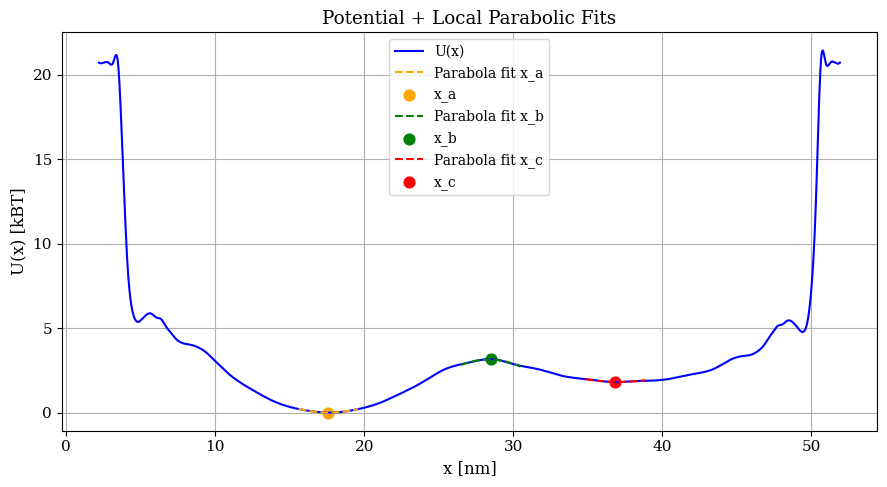

In [15]:
# compute_kramers_rates(bin_c[0], G1, D=3000, prominence=0.1, width=10, distance=50)  # Deconvolved U(x Talin 7pN)
compute_kramers_rates(bc1_s, U1_norm, D=3000, prominence=0.1, width=10, distance=50)  # Deconvolved U(x Talin 7pN)


Fit around x_a = 15.69 nm:
  Parabola: a = 5.533e-02, b = -1.730e+00, c = 16.063
  Curvature (2a) = 1.107e-01 kBT/nm²

Fit around x_b = 24.96 nm:
  Parabola: a = -9.394e-02, b = 4.683e+00, c = -53.234
  Curvature (2a) = -1.879e-01 kBT/nm²

Fit around x_c = 35.84 nm:
  Parabola: a = 3.415e-02, b = -2.428e+00, c = 46.539
  Curvature (2a) = 6.830e-02 kBT/nm²

ΔU unfolding = 2.60 kBT
ΔU folding   = 1.75 kBT
Unfolding rate = 5.0984e+00 s⁻¹
Folding rate   = 9.4401e+00 s⁻¹


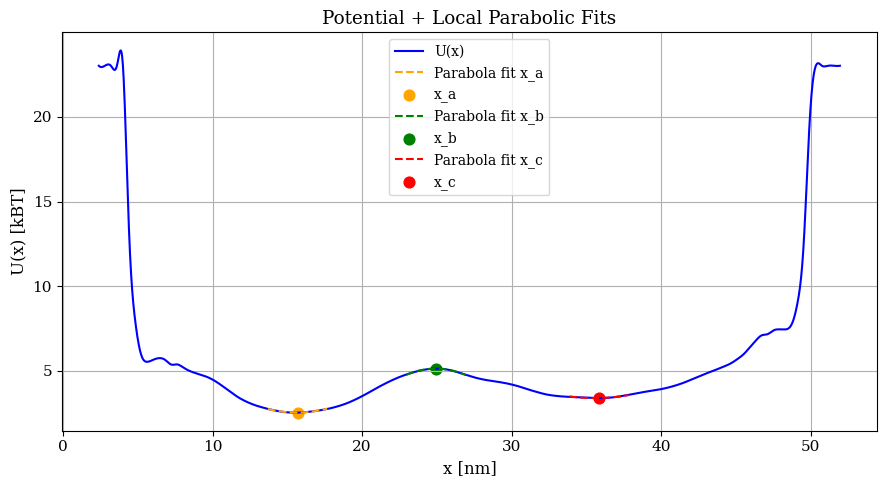


Fit around x_a = 15.69 nm:
  Parabola: a = 5.533e-02, b = -1.730e+00, c = 13.527
  Curvature (2a) = 1.107e-01 kBT/nm²

Fit around x_b = 24.96 nm:
  Parabola: a = -9.394e-02, b = 4.683e+00, c = -55.770
  Curvature (2a) = -1.879e-01 kBT/nm²

Fit around x_c = 35.84 nm:
  Parabola: a = 3.415e-02, b = -2.428e+00, c = 44.003
  Curvature (2a) = 6.830e-02 kBT/nm²

ΔU unfolding = 2.60 kBT
ΔU folding   = 1.75 kBT
Unfolding rate = 5.0984e+00 s⁻¹
Folding rate   = 9.4401e+00 s⁻¹


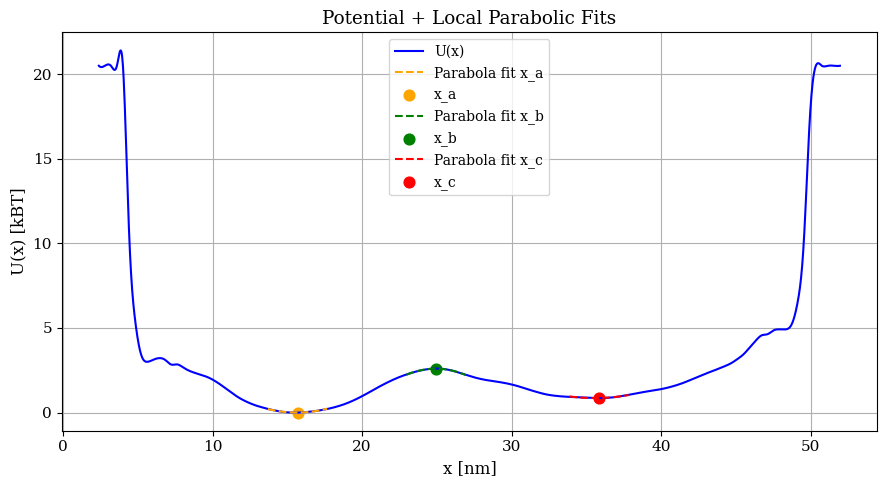

In [16]:
compute_kramers_rates(bin_c[1], G2, D=3000, prominence=0.1, width=10, distance=20)  #   deconvoluted U(x) Talin 8pN
compute_kramers_rates(bc2_s, U2, D=3000, prominence=0.1, width=10, distance=20)  #   deconvoluted U(x) Talin 8pN

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

def mfpt_analysis(x, U, D, prominence=0.4, width=10, distance=10):
    # --- Configurazione Stile ---
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 11,
        'axes.labelsize': 13,
        'mathtext.fontset': 'cm'
    })

    # Pulizia dati
    mask = np.isfinite(U)
    x_c = x[mask]
    U_c = U[mask]
    U_interp = interp1d(x_c, U_c, kind='cubic', fill_value='extrapolate')

    # Identificazione punti critici
    min_idx, _ = find_peaks(-U, prominence=prominence, width=width, distance=distance)
    max_idx, _ = find_peaks(U, prominence=prominence, width=width, distance=distance)
    
    if len(min_idx) < 2: return None
    
    x_f, x_u = sorted([x[min_idx[0]], x[min_idx[1]]])
    # Troviamo il massimo tra i due minimi
    mask_ts = (x_c > x_f) & (x_c < x_u)
    x_b = x_c[mask_ts][np.argmax(U_c[mask_ts])]

    # --- Calcolo MFPT Ottimizzato (Veloce) ---
    x_fine = np.linspace(x_c.min(), x_c.max(), 5000)
    dx = x_fine[1] - x_fine[0]
    U_fine = U_interp(x_fine)
    
    def get_rate(start, end, reflect):
        exp_minus = np.exp(-U_fine)
        exp_plus = np.exp(U_fine)
        
        # Integrale interno cumulativo
        idx_refl = np.argmin(np.abs(x_fine - reflect))
        inner = cumulative_trapezoid(exp_minus, x_fine, initial=0)
        inner -= inner[idx_refl]
        
        # Integrale esterno tra start e end
        integrand = exp_plus * inner
        mask_int = (x_fine >= min(start, end)) & (x_fine <= max(start, end))
        tau = np.abs(np.trapz(integrand[mask_int], x_fine[mask_int])) / D
        return 1.0 / tau

    k_unf = get_rate(x_f, x_u, x_f - 4.5)
    k_fld = get_rate(x_u, x_f, x_u + 4.5)

    # --- Plot Professionale ---
    fig, ax = plt.subplots(figsize=(8, 5.5))
    
    # Plot del potenziale
    ax.plot(x_fine, U_fine, color='#2c3e50', lw=2, label=r'Free Energy $U(z)$')
    
    # Evidenziazione punti critici con colori professionali
    ax.scatter(x_f, U_interp(x_f), color='#27ae60', s=80, zorder=5, label='Folded ($z_F$)', edgecolors='black')
    ax.scatter(x_b, U_interp(x_b), color='#c0392b', s=80, zorder=5, label='Barrier ($z_{TS}$)', edgecolors='black')
    ax.scatter(x_u, U_interp(x_u), color='#f39c12', s=80, zorder=5, label='Unfolded ($z_U$)', edgecolors='black')

    # Label e stile
    ax.set_xlabel(r'Extension $z$ [nm]')
    ax.set_ylabel(r'Free Energy $U$ [$k_B T$]')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Box informativo con i risultati dei rate
    res_text = (f'$k_{{unf}} = {k_unf:.2e}$ s$^{{-1}}$\n'
                f'$k_{{fld}} = {k_fld:.2e}$ s$^{{-1}}$\n'
                f'$\Delta U^\ddagger_{{unf}} = {U_interp(x_b)-U_interp(x_f):.2f}$ $k_BT$')
    
    ax.text(0.05, 0.95, res_text, transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#bdc3c7'))

    ax.legend(loc='lower right', frameon=False)
    
    plt.tight_layout()
    plt.show()

    return k_fld, k_unf

# Esempio d'uso:
# k_f, k_u = mfpt_analysis_professional(bc1_s, U1_norm, D=3000)

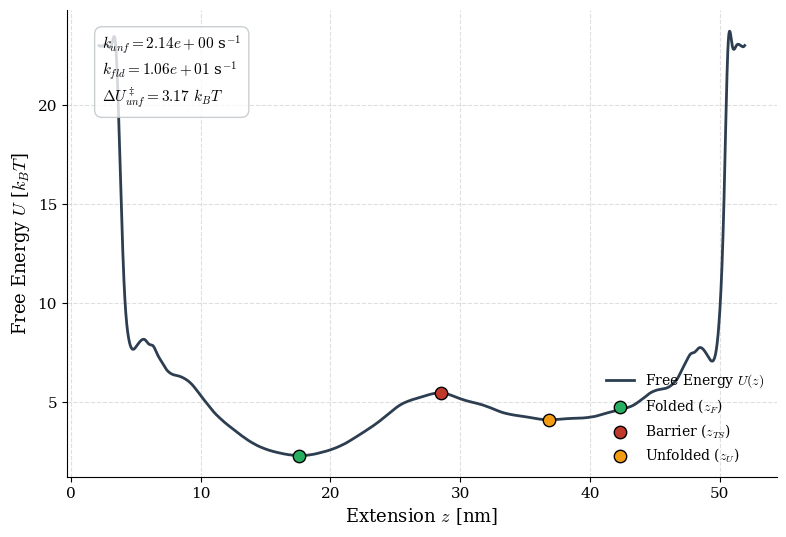

(10.649444427025308, 2.1437171279538894)

In [18]:
mfpt_analysis(bin_c[0], G1, D = 3000)  

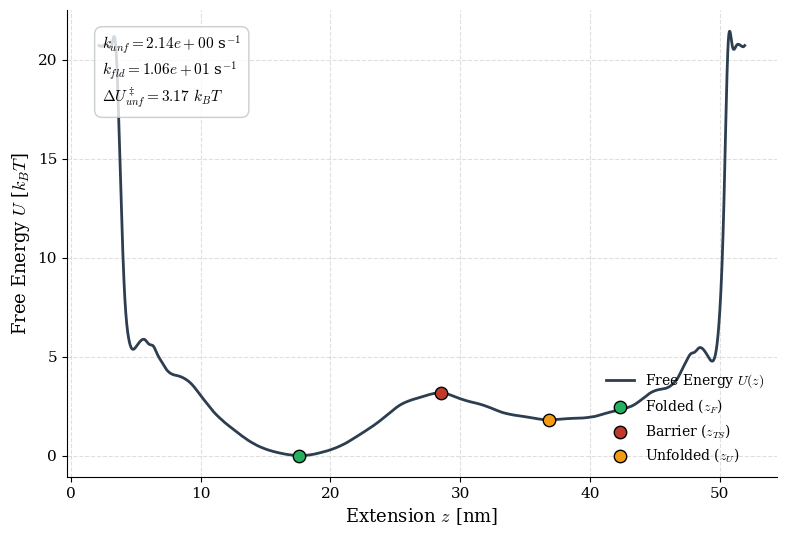

(10.649444427025479, 2.1437171279538907)

In [19]:
mfpt_analysis(bc1_s, U1_norm, D =3000)

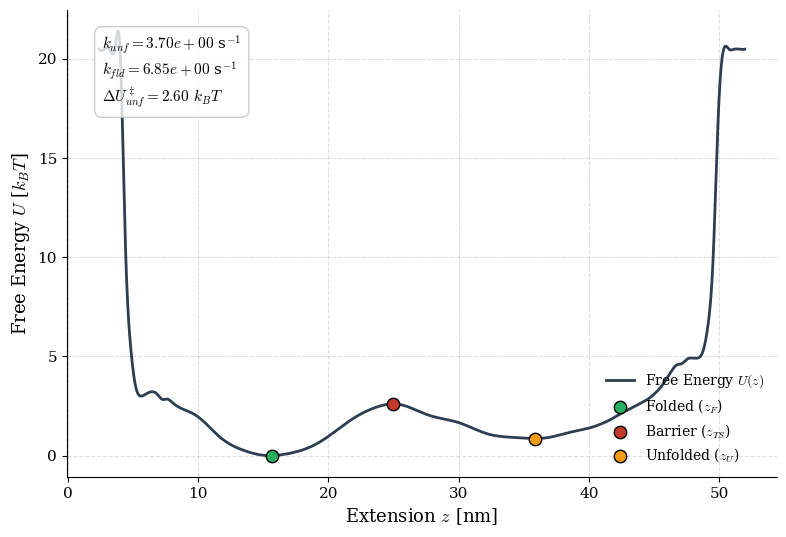

(6.848991713405713, 3.702010291850501)

In [20]:
mfpt_analysis(bc2_s, U2_norm, D =3000)

Text(0.5, 1.0, 'Rate comparison: low(MFPT).Mid(dwelltime).up(kramer)')

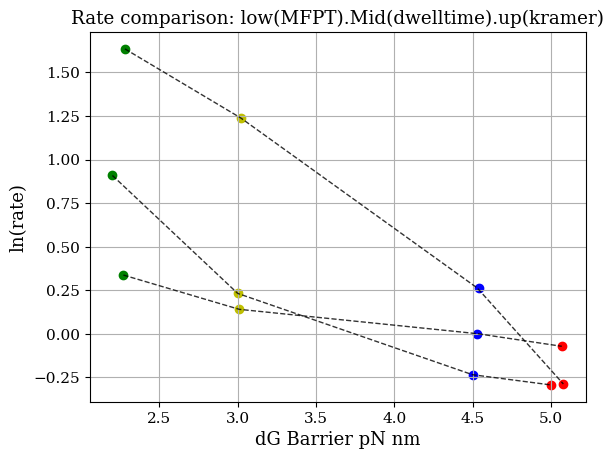

In [21]:

plt.scatter(x= 5, y=np.log(0.745), c="r", label="Langevan Unfold")
plt.scatter(x=5.07, y=np.log(0.93), c="r", label="deconvolution Unfold")
plt.scatter(x=5.08, y=np.log(0.749), c="r", label="Kramer Unfold")

plt.scatter(x= 2.2, y=np.log(2.48), c="g", label="Langevan Fold")
plt.scatter(x=2.27, y=np.log(1.4), c="g", label="deconvolution Fold")
plt.scatter(x=2.28, y=np.log(5.13), c="g", label="Kramer Fold")


plt.scatter(x= 4.5, y=np.log(0.79), c="b", label="Langevan Unfold")
plt.scatter(x=4.53, y=np.log(1), c="b", label="deconvolution unFold")
plt.scatter(x=4.54 , y=np.log(1.3), c="b", label="Kramer unFold")

plt.scatter(x= 3, y=np.log(1.26), c="y", label="Langevan Fold")
plt.scatter(x= 3.01, y=np.log(1.15), c="y", label="deconvolution Fold")
plt.scatter(x=3.02, y=np.log(3.45), c="y", label="Kramer Fold")

plt.grid(True)
plt.ylabel("ln(rate)")
plt.xlabel("dG Barrier pN nm")

# Dati
langevin_x = [5,2.2,4.5,3]
langevin_y = np.log([0.745,2.48,0.79, 1.26])

deconv_x = [5.07, 2.27, 4.53, 3.01 ]
deconv_y = np.log([0.93, 1.4,1, 1.15])

kramer_x = [5.08, 2.28, 4.53, 3.02]
kramer_y = np.log([0.749, 5.13, 1.3, 3.45])

langevin_sorted = sorted(zip(langevin_x, langevin_y))
deconv_sorted = sorted(zip(deconv_x, deconv_y))
kramer_sorted = sorted(zip(kramer_x, kramer_y))

langevin_x_sorted, langevin_y_sorted = zip(*langevin_sorted)
deconv_x_sorted, deconv_y_sorted = zip(*deconv_sorted)
kramer_x_sorted , kramer_y_sorted = zip(*kramer_sorted)

plt.plot(langevin_x_sorted, langevin_y_sorted, c = "black", alpha=0.8, linestyle="--", lw = 1)
plt.plot(deconv_x_sorted, deconv_y_sorted, c = "black", alpha = 0.8, linestyle="--", lw=1)
plt.plot(kramer_x_sorted, kramer_y_sorted, c = "black", alpha = 0.8, linestyle="--", lw=1)
plt.title("Rate comparison: low(MFPT).Mid(dwelltime).up(kramer)")
# inchoerence may come from different shape of the barrier: in Langevan analysis it's way broader